In [6]:
from data_preparation import prepare_dataset, get_loss_weights
from graph_construction import build_graph
from train_and_evaluate import (
    train_and_evaluate,
    train_mlp
)
from models import (
    Transformer_Model,
    RGCN_Model,
    GAT_Model,
    BaselineMLP
)
from resources import (
    DATA_PATH,
    DEVICE,
    OUTPUT_TABLES_PATH,
    OUTPUT_FIGURES_PATH
)

EPOCHS = 500
PATIENCE = 30

In [7]:
import pandas as pd
import torch
import os
import numpy as np

In [8]:
x, y, pos_combined, pos_spatial, pos_temporal, group_ids = prepare_dataset(DATA_PATH, return_group_ids=True)
class_weights = get_loss_weights(y = y)

There are 10034 natural fires (56.44 %) [all]
There are 7744 human made fires (43.56 %) [all]


# STRUCTURAL ABLATION

In [9]:
NUM_RUNS = 5

## Training with LogArea as only node feature - trying to isolate topology

In [10]:

graph_types = ['spatial', 'temporal', 'combined', 'multirelational']
k_values = [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]
architectures = ['RGCN', 'GAT', 'TransformerConv']

results = []

print(f"\nStarting Comprehensive Ablation Study ({NUM_RUNS} runs per config)...")
for g_type in graph_types:
    for k in k_values:
        data = build_graph(g_type, k, pos_spatial, pos_temporal, pos_combined, x, y, group_ids=group_ids)
        in_dim = data.x.size(1) 
        edge_dim = data.edge_attr.size(1)

        for arch in architectures:
            run_f1s = []
            run_accs = []
            
            for run in range(NUM_RUNS):
                if arch == 'RGCN':
                    model = RGCN_Model(input_dim=in_dim, hidden_dim=16)
                elif arch == 'GAT':
                    model = GAT_Model(input_dim=in_dim, hidden_dim=16, edge_dim=edge_dim)
                elif arch == 'TransformerConv':
                    model = Transformer_Model(input_dim=in_dim, hidden_dim=16, edge_dim=edge_dim)

                f1, acc, _ = train_and_evaluate(model, data, DEVICE, class_weights, EPOCHS, PATIENCE)
                run_f1s.append(f1)
                run_accs.append(acc)

            avg_f1, std_f1 = np.mean(run_f1s), np.std(run_f1s)
            avg_acc, std_acc = np.mean(run_accs), np.std(run_accs)

            print(f"Graph: {g_type.upper():<10} | K: {k:<2} | Model: {arch:<15} | F1: {avg_f1:.4f} ± {std_f1:.4f}")
            
            results.append({
                'Graph': g_type,
                'K': k,
                'Model': arch,
                'F1': avg_f1,
                'F1_std': std_f1,
                'Accuracy': avg_acc,
                'Accuracy_std': std_acc
            })

topology_comparison_df = pd.DataFrame(results)
topology_comparison_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "topology_comparison_df.csv"))


Starting Comprehensive Ablation Study (5 runs per config)...
Graph: SPATIAL    | K: 5  | Model: RGCN            | F1: 0.5562 ± 0.0281
Graph: SPATIAL    | K: 5  | Model: GAT             | F1: 0.5653 ± 0.0050
Graph: SPATIAL    | K: 5  | Model: TransformerConv | F1: 0.5272 ± 0.0466
Graph: SPATIAL    | K: 7  | Model: RGCN            | F1: 0.5463 ± 0.0382
Graph: SPATIAL    | K: 7  | Model: GAT             | F1: 0.5498 ± 0.0423
Graph: SPATIAL    | K: 7  | Model: TransformerConv | F1: 0.5663 ± 0.0418
Graph: SPATIAL    | K: 9  | Model: RGCN            | F1: 0.5612 ± 0.0263
Graph: SPATIAL    | K: 9  | Model: GAT             | F1: 0.5646 ± 0.0073
Graph: SPATIAL    | K: 9  | Model: TransformerConv | F1: 0.5863 ± 0.0038
Graph: SPATIAL    | K: 11 | Model: RGCN            | F1: 0.5258 ± 0.0580
Graph: SPATIAL    | K: 11 | Model: GAT             | F1: 0.5294 ± 0.0814
Graph: SPATIAL    | K: 11 | Model: TransformerConv | F1: 0.5685 ± 0.0425
Graph: SPATIAL    | K: 13 | Model: RGCN            | F1: 0.556

## Training MLP baselines (spatial, temporal and combined)

In [11]:
HIDDEN_UNITS = 16

train_mask = data.train_mask.to(DEVICE)
val_mask = data.val_mask.to(DEVICE)
test_mask = data.test_mask.to(DEVICE)

x_mlp_spatial = torch.cat([x, pos_spatial], dim=1)           # [LogArea, Lat, Lon]
x_mlp_temporal = torch.cat([x, pos_temporal], dim=1)         # [LogArea, Days]
x_mlp_combined = torch.cat([x, pos_spatial, pos_temporal], dim=1) # [LogArea, Lat, Lon, Days]

mlp_configs = [
    ('MLP_Spatial', x_mlp_spatial, 3),
    ('MLP_Temporal', x_mlp_temporal, 2),
    ('MLP_Combined', x_mlp_combined, 4)
]

mlp_results = []
print(f"\n--- Running MLP Baselines ({NUM_RUNS} runs each) ---")

for name, input_tensor, in_features in mlp_configs:
    run_f1s = []
    run_accs = []
    
    for run in range(NUM_RUNS):
        model = BaselineMLP(in_features, HIDDEN_UNITS).to(DEVICE)
        f1, acc, _ = train_mlp(model, input_tensor, y, train_mask, val_mask, test_mask, DEVICE, class_weights, epochs=EPOCHS)
        run_f1s.append(f1)
        run_accs.append(acc)
    
    mlp_results.append({
        'Graph': name,
        'K': 0,
        'Model': 'MLP',
        'F1': np.mean(run_f1s),
        'F1_std': np.std(run_f1s),
        'Accuracy': np.mean(run_accs),
        'Accuracy_std': np.std(run_accs)
    })

results_mlp_df = pd.DataFrame(mlp_results)
mlp_topology_comparison_df = pd.concat([topology_comparison_df, results_mlp_df], ignore_index=True)

mlp_topology_comparison_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "mlp_topology_comparison.csv"))


--- Running MLP Baselines (5 runs each) ---


## Getting result tables

In [15]:
# if already available, just load previous results
mlp_topology_comparison_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "mlp_topology_comparison.csv"))
topology_comparison_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "topology_comparison_df.csv"))

In [16]:
def get_paper_ready_table(df, group_by_col):
    # 1. Find best based on Mean F1
    idx = df.groupby(group_by_col)['F1'].idxmax()
    table = df.loc[idx].copy()
    
    # 2. Create "Mean ± Std" strings
    table['F1 Score'] = table.apply(lambda r: f"{r['F1']:.4f} ± {r['F1_std']:.4f}", axis=1)
    table['Accuracy Score'] = table.apply(lambda r: f"{r['Accuracy']:.4f} ± {r['Accuracy_std']:.4f}", axis=1)
    
    return table

# --- ARCHITECTURAL COMPARISON ---
arch_table = get_paper_ready_table(mlp_topology_comparison_df, 'Model')
arch_table = arch_table[['Model', 'Graph', 'K', 'F1 Score', 'Accuracy Score']].sort_values(by='F1 Score', ascending=False)
print("\n--- BEST OF EACH ARCHITECTURE (5-RUN AVG) ---")
print(arch_table.to_string(index=False))

# --- TOPOLOGY COMPARISON ---
topo_table = get_paper_ready_table(mlp_topology_comparison_df, 'Graph')
topo_table = topo_table.rename(columns={'Graph': 'Topology Construction'})
topo_table = topo_table[['Topology Construction', 'Model', 'K', 'F1 Score', 'Accuracy Score']].sort_values(by='F1 Score', ascending=False)
print("\n--- BEST OF EACH TOPOLOGY (5-RUN AVG) ---")
print(topo_table.to_string(index=False))


--- BEST OF EACH ARCHITECTURE (5-RUN AVG) ---
          Model           Graph  K        F1 Score  Accuracy Score
TransformerConv multirelational 29 0.6659 ± 0.0032 0.6734 ± 0.0028
           RGCN        temporal 21 0.6397 ± 0.0039 0.6448 ± 0.0061
            GAT multirelational 31 0.6214 ± 0.0182 0.6274 ± 0.0184
            MLP     MLP_Spatial  0 0.5884 ± 0.0345 0.6253 ± 0.0297

--- BEST OF EACH TOPOLOGY (5-RUN AVG) ---
Topology Construction           Model  K        F1 Score  Accuracy Score
      multirelational TransformerConv 29 0.6659 ± 0.0032 0.6734 ± 0.0028
             temporal            RGCN 21 0.6397 ± 0.0039 0.6448 ± 0.0061
             combined TransformerConv 21 0.6229 ± 0.0337 0.6260 ± 0.0296
              spatial TransformerConv 23 0.5921 ± 0.0217 0.5965 ± 0.0196
          MLP_Spatial             MLP  0 0.5884 ± 0.0345 0.6253 ± 0.0297
         MLP_Combined             MLP  0 0.5720 ± 0.0312 0.6146 ± 0.0153
         MLP_Temporal             MLP  0 0.4149 ± 0.0668 0.5437 

## Plotting Topology vs BestMLP with all features

/tmp/ipykernel_24690/2575981654.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lift_df, x='Model', y='F1 Score', palette=['#d9534f', '#5bc0de'])


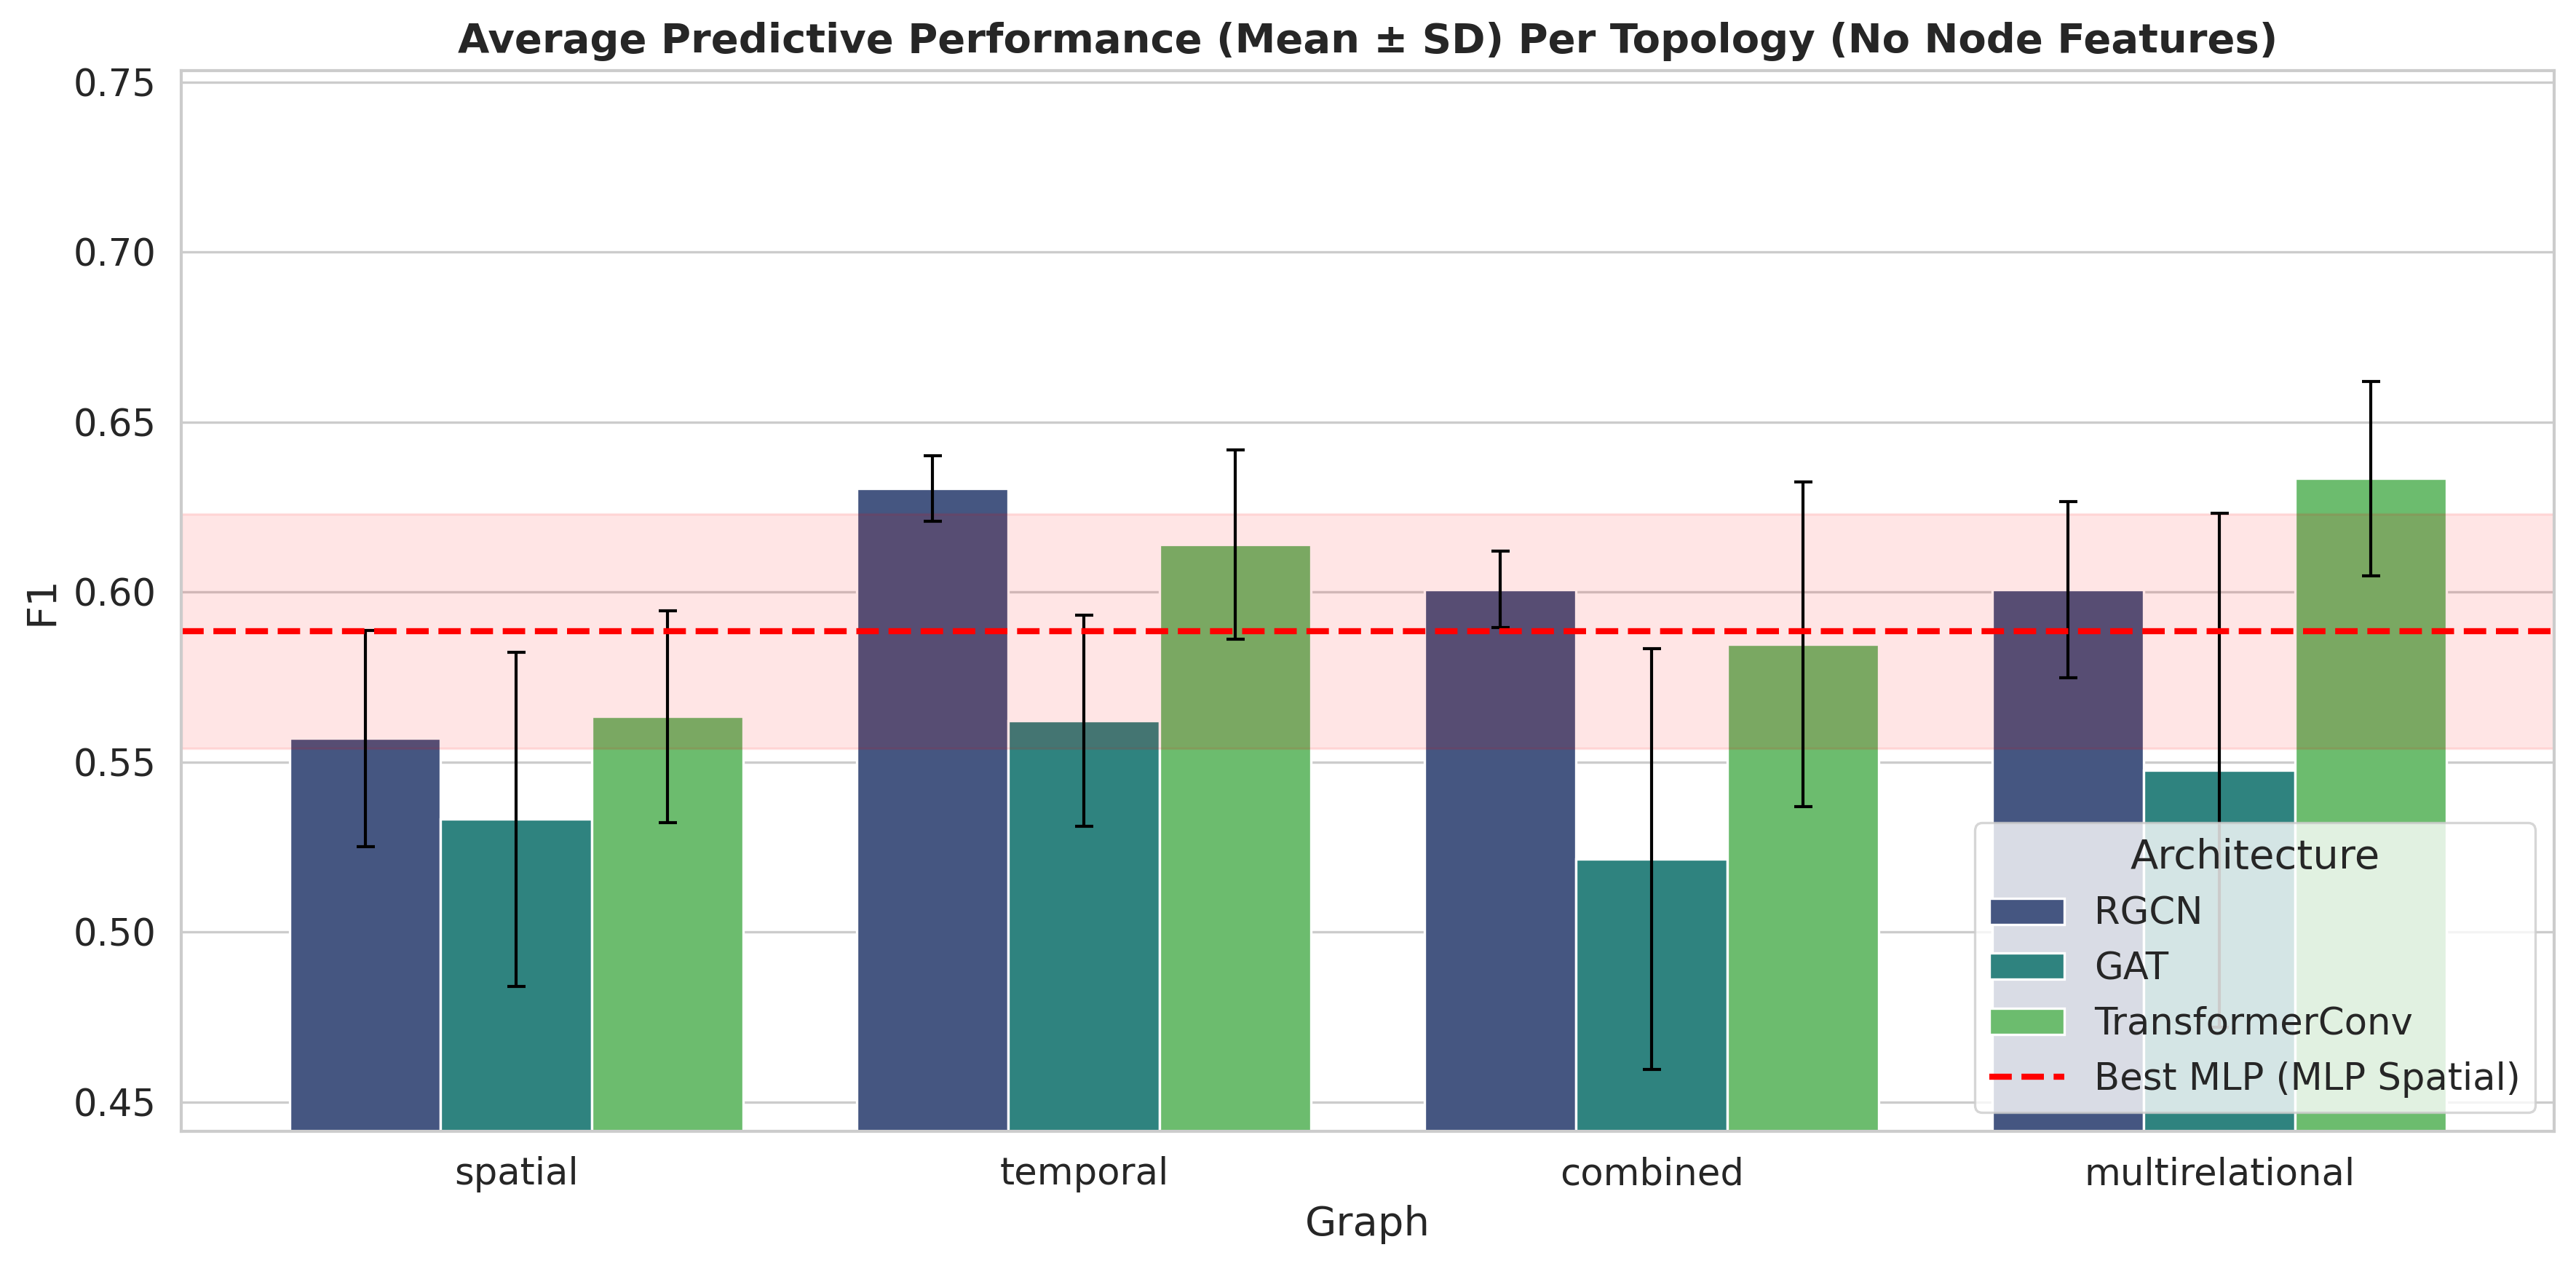

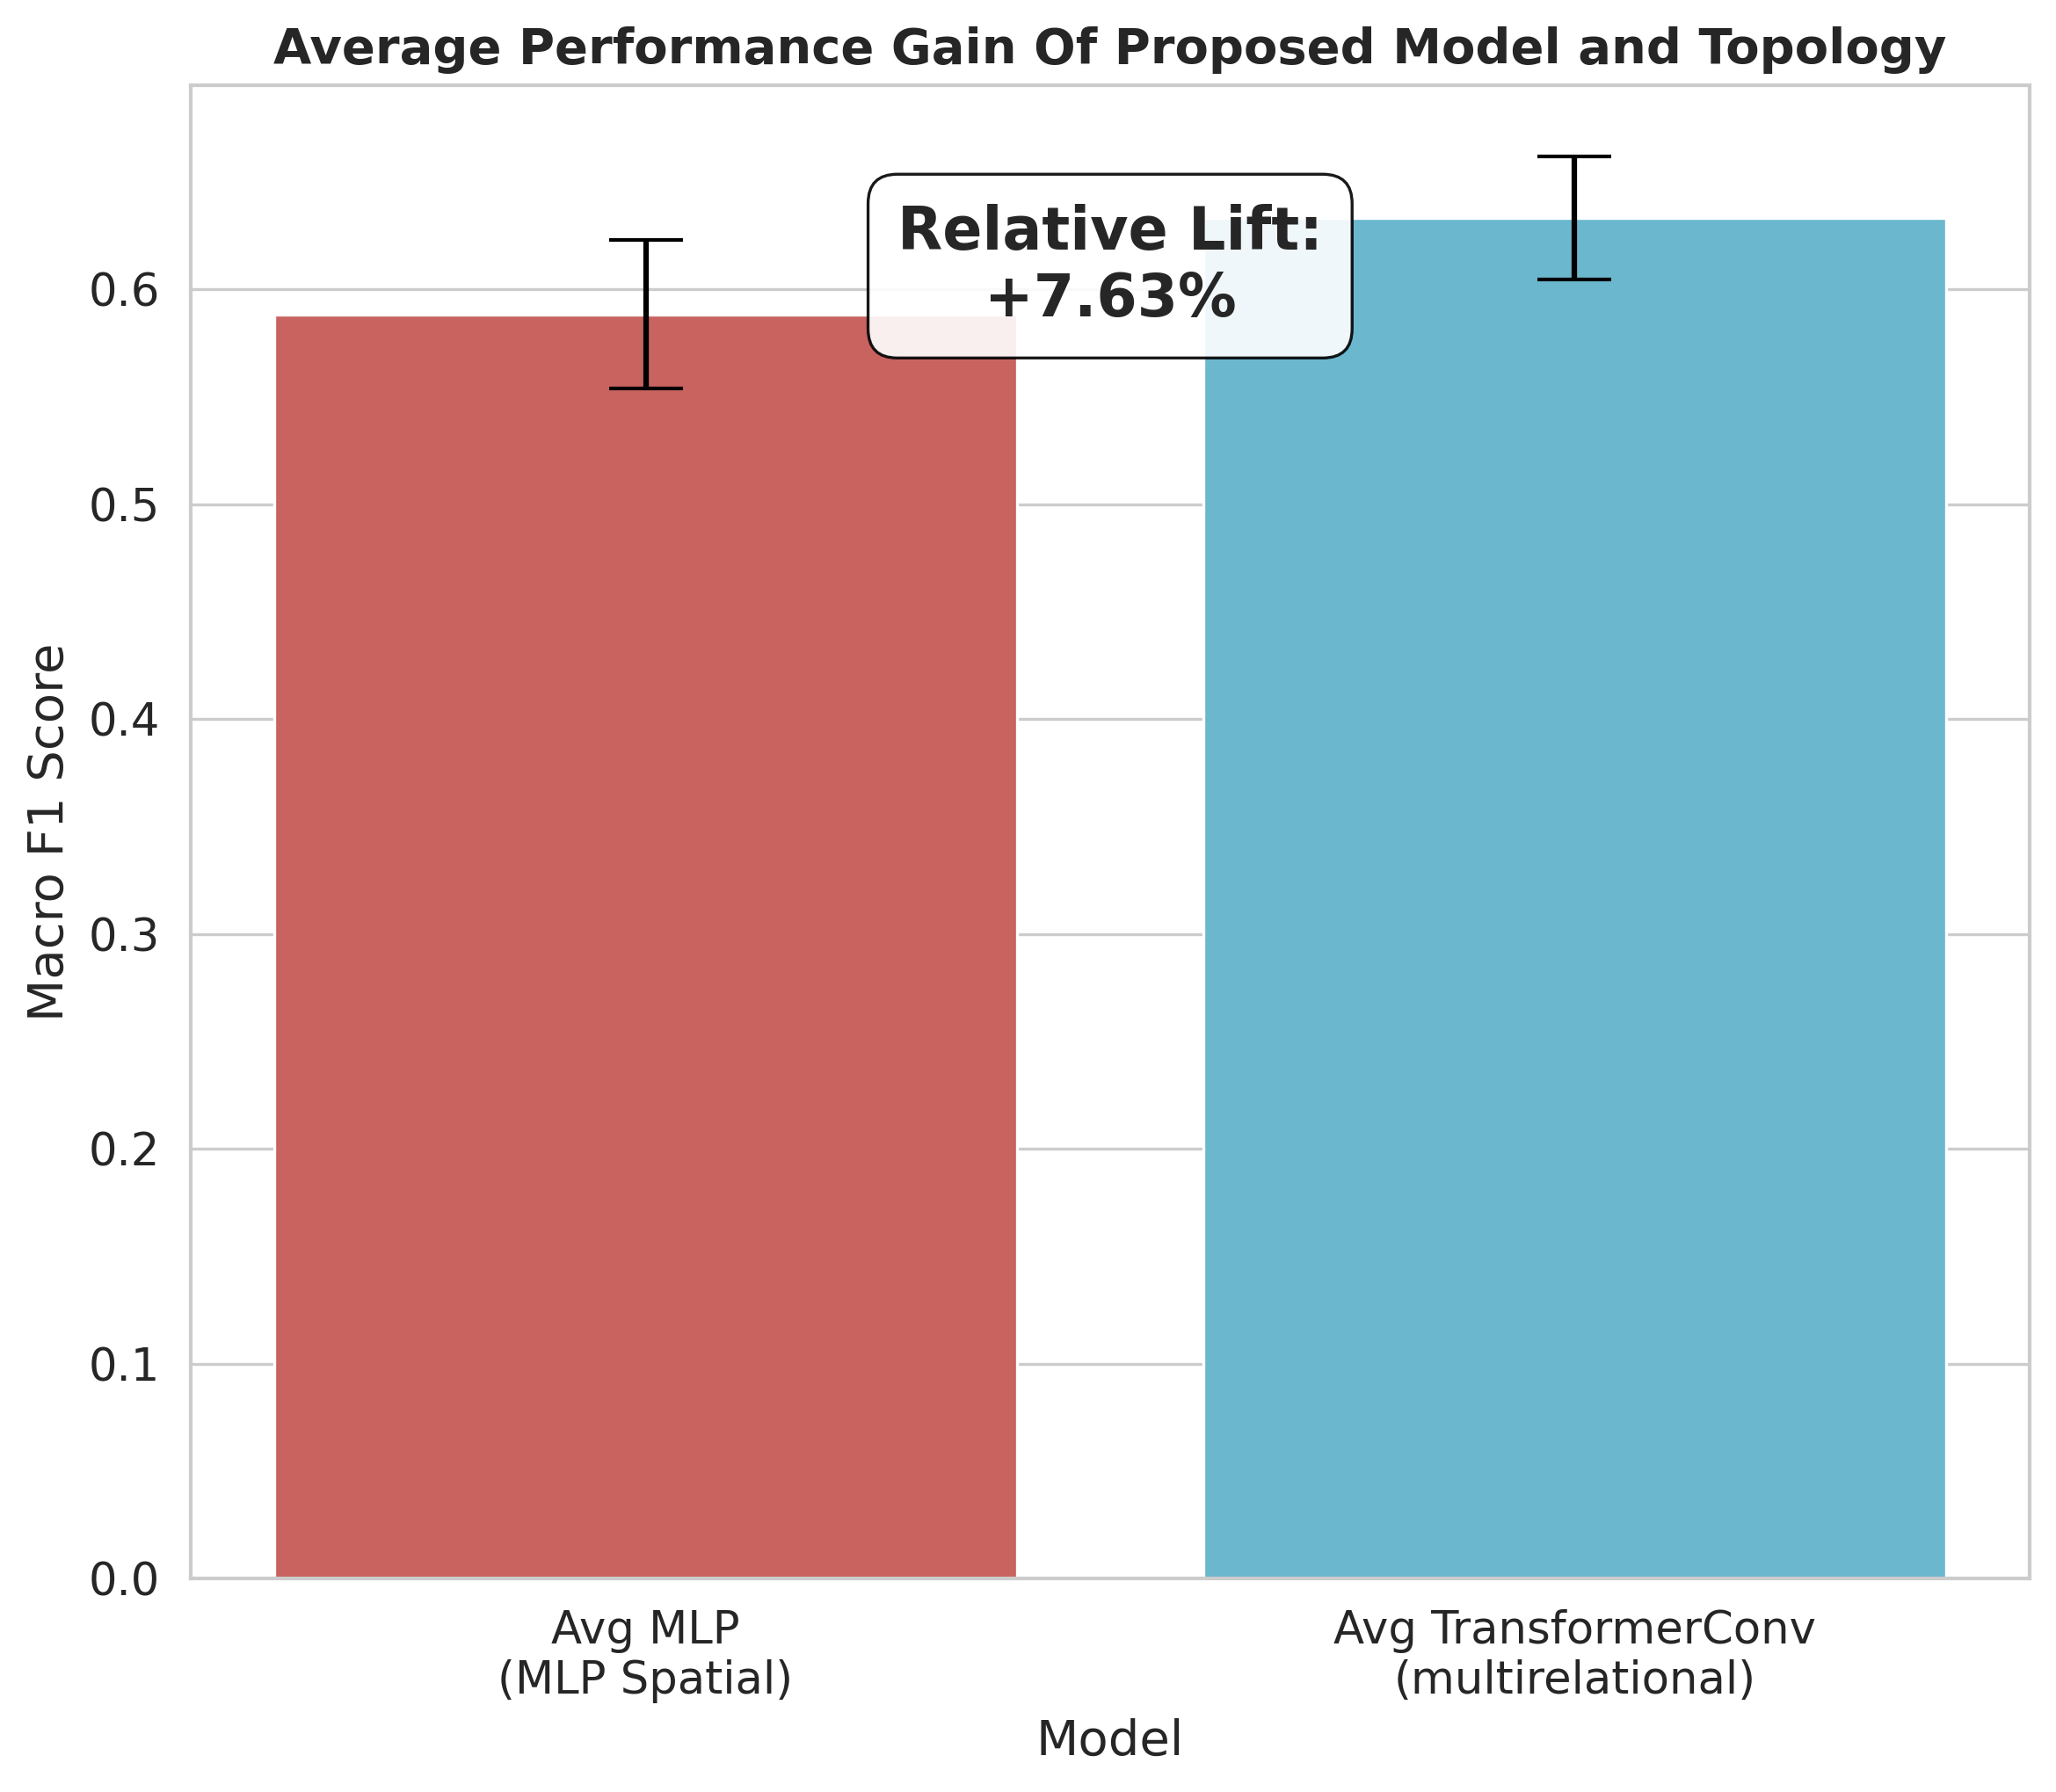

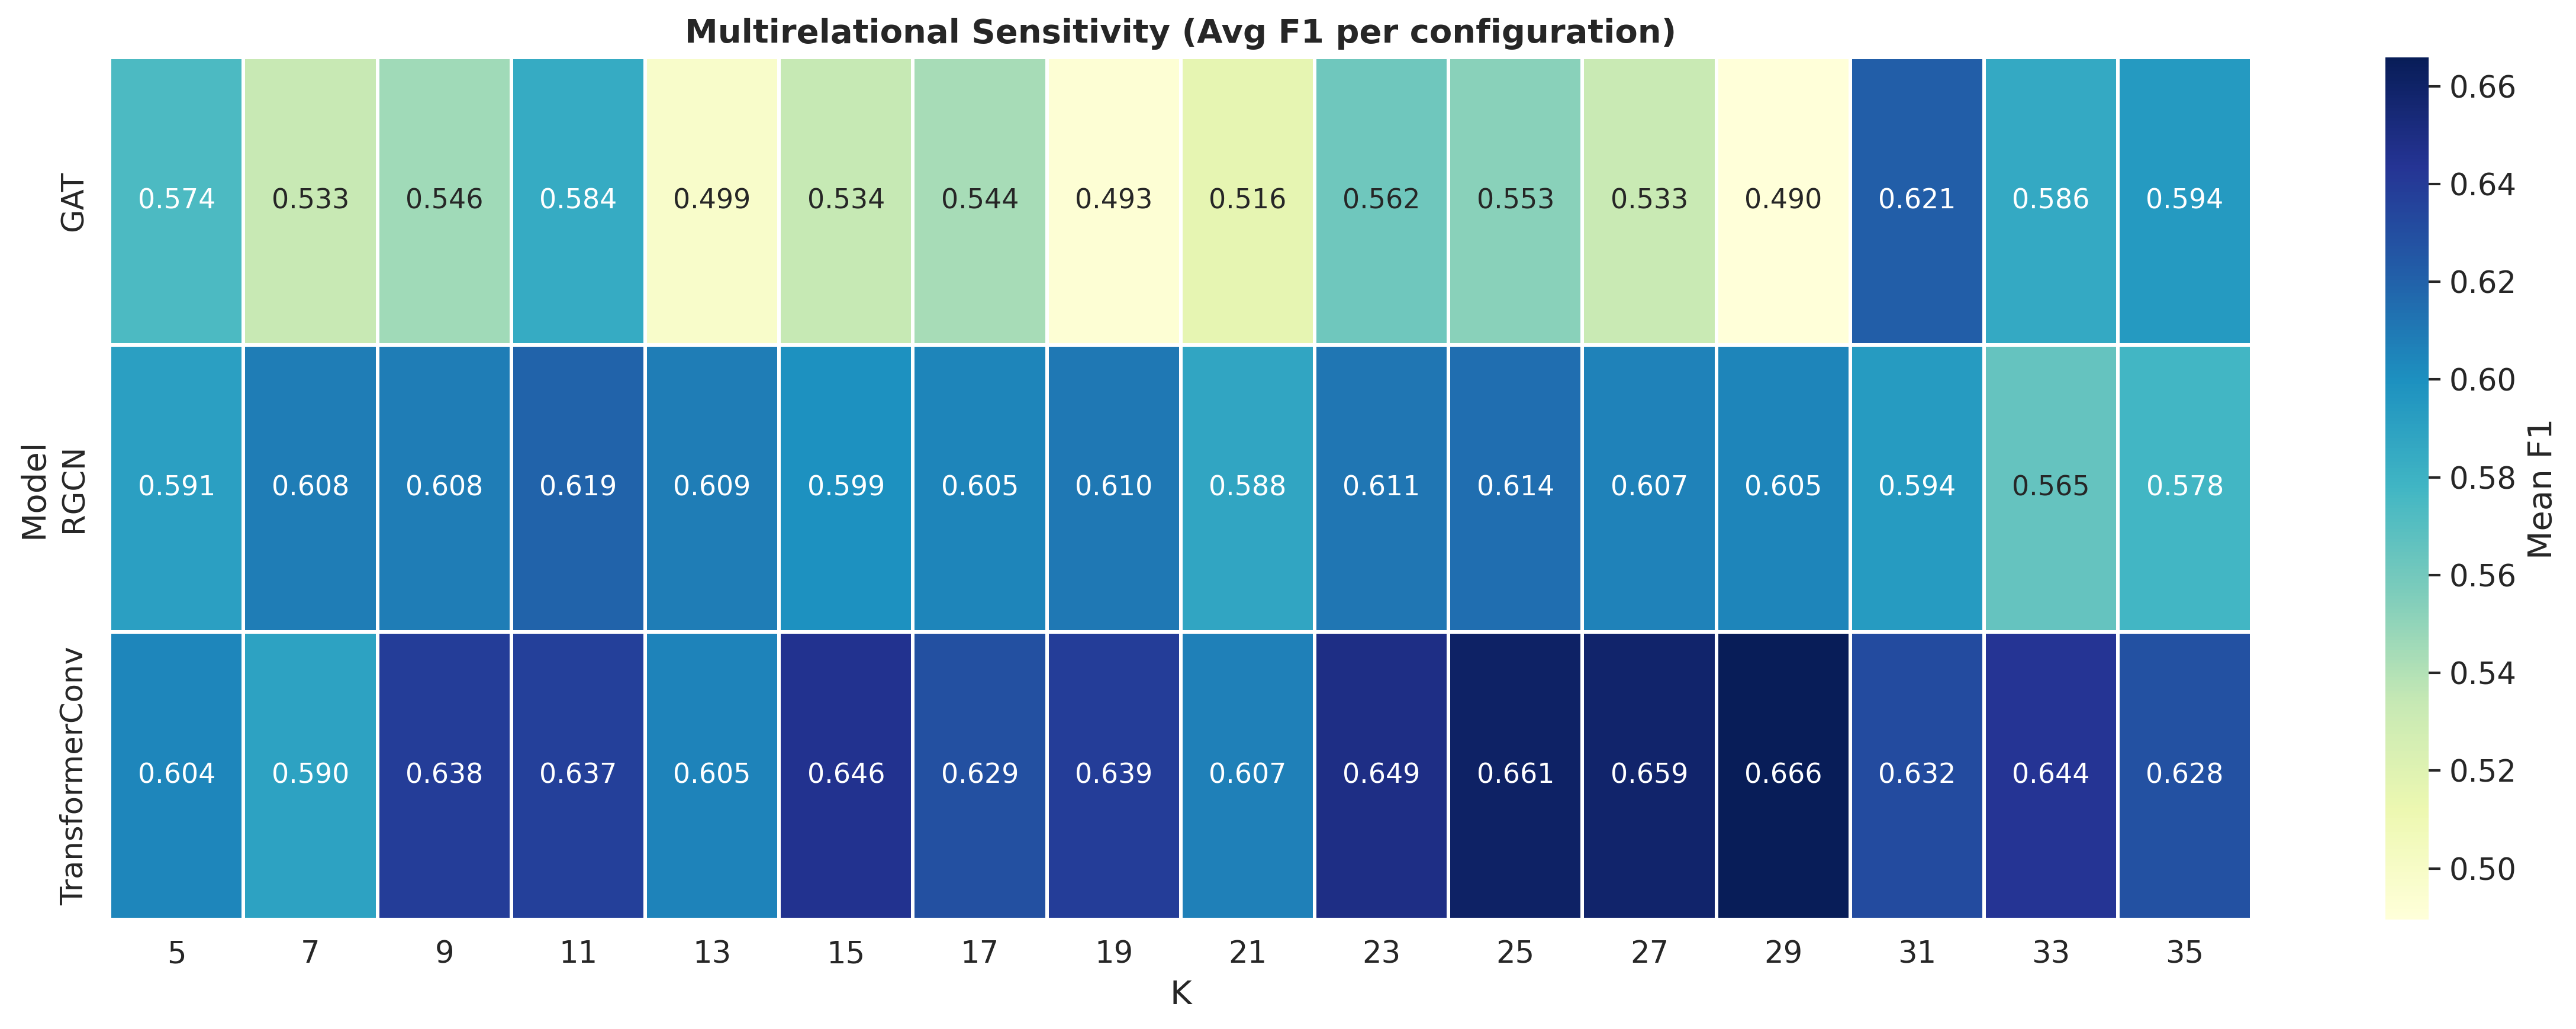

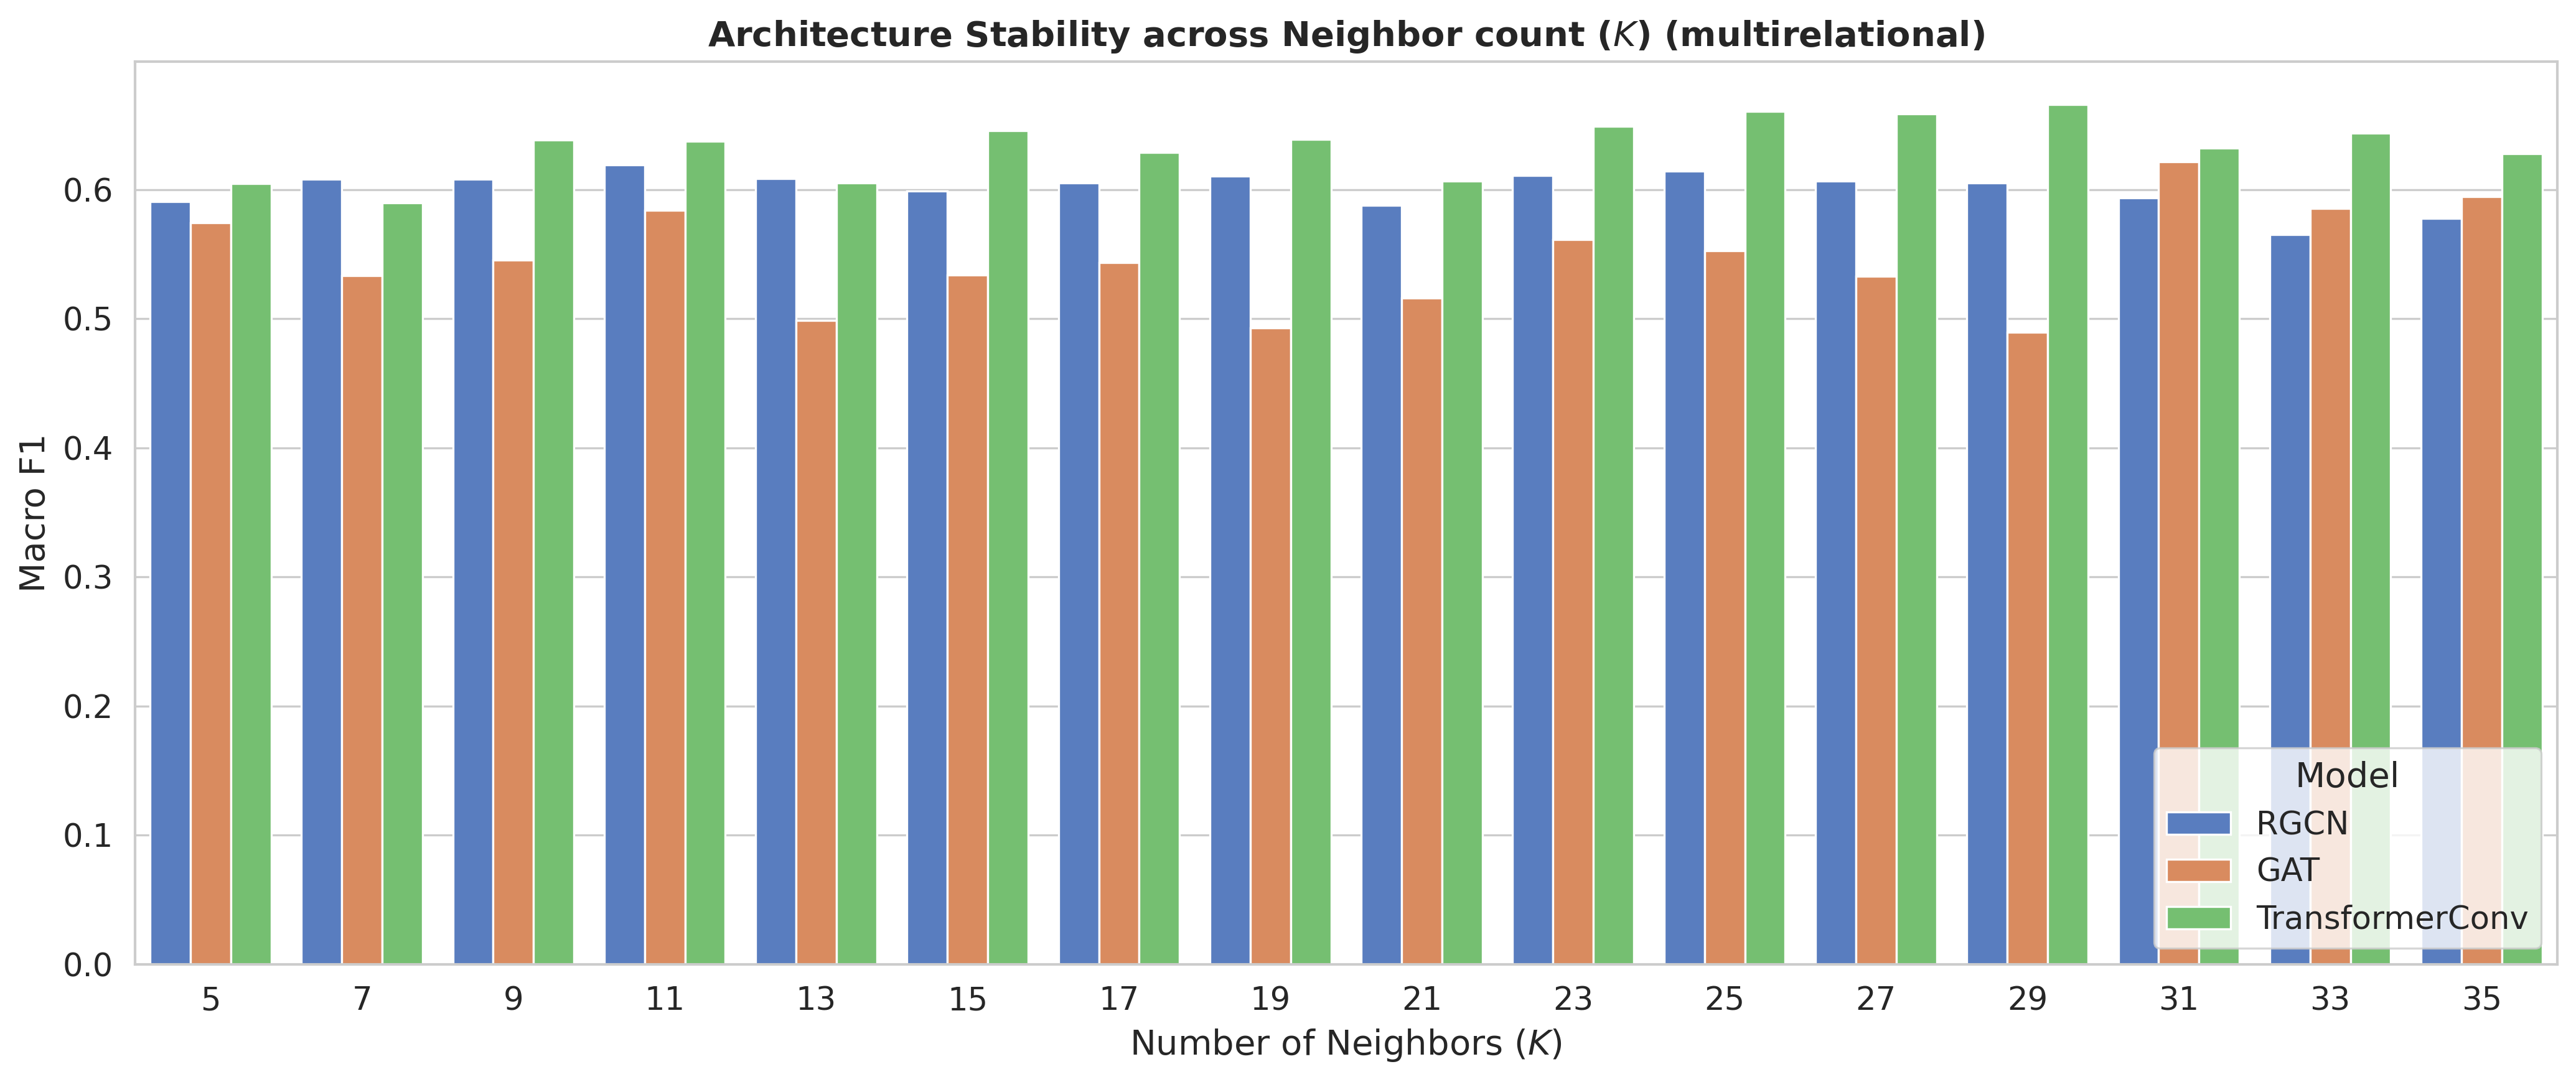

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

def plot_wildfire_results(results_df, final_comparison_df, OUTPUT_FIGURES_PATH):
    if not os.path.exists(OUTPUT_FIGURES_PATH):
        os.makedirs(OUTPUT_FIGURES_PATH)

    # Set style - restored to your original scaling
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
    graph_order = ['spatial', 'temporal', 'combined', 'multirelational']
    architectures = ['RGCN', 'GAT', 'TransformerConv']
    
    # ---------------------------------------------------------
    # 0. DATA PREPARATION (Average Metrics)
    # ---------------------------------------------------------
    mlp_subset = final_comparison_df[final_comparison_df['Model'] == 'MLP']
    if not mlp_subset.empty:
        # We take the BEST MLP variant but use its mean and std
        best_mlp = mlp_subset.sort_values(by='F1', ascending=False).iloc[0]
        mlp_f1 = best_mlp['F1']
        mlp_std = best_mlp['F1_std']
        mlp_name = best_mlp['Graph'].replace('_', ' ')
    else:
        mlp_f1, mlp_std, mlp_name = 0.5, 0.0, "Baseline"

    # ---------------------------------------------------------
    # 1. AVERAGE PERFORMANCE PER TOPOLOGY
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 6), dpi=300)
    
    # Calculate Average Performance for every Topology/Model combination
    topo_avg = results_df.groupby(['Graph', 'Model']).agg({'F1': 'mean', 'F1_std': 'mean'}).reset_index()
    topo_avg['Graph'] = pd.Categorical(topo_avg['Graph'], categories=graph_order, ordered=True)
    topo_avg['Model'] = pd.Categorical(topo_avg['Model'], categories=architectures, ordered=True)
    topo_avg = topo_avg.sort_values(['Graph', 'Model'])

    ax = sns.barplot(data=topo_avg, x='Graph', y='F1', hue='Model', 
                     order=graph_order, palette='viridis', capsize=.05)
    
    # Correct Error Bar Mapping for Averages
    for i, model_name in enumerate(architectures):
        model_data = topo_avg[topo_avg['Model'] == model_name].set_index('Graph').reindex(graph_order)
        means = model_data['F1'].values
        errors = model_data['F1_std'].values
        x_coords = [rect.get_x() + rect.get_width() / 2 for rect in ax.containers[i]]
        plt.errorbar(x=x_coords, y=means, yerr=errors, fmt='none', c='black', capsize=3, elinewidth=1)

    # RESTORED: MLP Baseline with shaded STD band
    plt.axhline(mlp_f1, color='red', linestyle='--', linewidth=2, label=f'Best MLP ({mlp_name})')
    plt.axhspan(mlp_f1 - mlp_std, mlp_f1 + mlp_std, color='red', alpha=0.1)
    
    plt.ylim(min(topo_avg['F1'].min(), mlp_f1) - 0.08, max(topo_avg['F1'].max(), mlp_f1) + 0.12)
    plt.title("Average Predictive Performance (Mean ± SD) Per Topology (No Node Features)", fontweight='bold')
    
    # RESTORED: Legend over the plot
    plt.legend(title="Architecture", loc='lower right', frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIGURES_PATH, '01_avg_f1_comparison.png'))

    # ---------------------------------------------------------
    # 2. PERFORMANCE LIFT (Avg GNN vs Avg MLP)
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 7), dpi=300)
    # Comparison of the single best topology (average) vs best MLP (average)
    best_overall_topo = topo_avg.sort_values(by='F1', ascending=False).iloc[0]
    
    lift_val = ((best_overall_topo['F1'] - mlp_f1) / mlp_f1) * 100
    
    lift_df = pd.DataFrame({
        'Model': [f'Avg MLP\n({mlp_name})', f"Avg {best_overall_topo['Model']}\n({best_overall_topo['Graph']})"],
        'F1 Score': [mlp_f1, best_overall_topo['F1']],
        'std': [mlp_std, best_overall_topo['F1_std']]
    })
    
    sns.barplot(data=lift_df, x='Model', y='F1 Score', palette=['#d9534f', '#5bc0de'])
    plt.errorbar(x=[0, 1], y=lift_df['F1 Score'], yerr=lift_df['std'], fmt='none', c='black', capsize=10, elinewidth=1.5)
    
    plt.text(0.5, (best_overall_topo['F1'] + mlp_f1)/2, f"Relative Lift:\n{lift_val:+.2f}%", 
             ha='center', va='center', fontsize=16, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

    plt.title("Average Performance Gain Of Proposed Model and Topology (No Node Features)", fontweight='bold')
    plt.ylabel('Macro F1 Score')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIGURES_PATH, '02_topology_performance_lift.png'))

    # ---------------------------------------------------------
    # 3. SENSITIVITY HEATMAP (Expanded & Decoupled)
    # ---------------------------------------------------------
    # Multirelational only
    m_data = results_df[results_df['Graph'] == 'multirelational']
    if not m_data.empty:
        # Increase width significantly for readability
        plt.figure(figsize=(16, 6), dpi=300)
        pivot_heat = m_data.pivot_table(index="Model", columns="K", values="F1", aggfunc='mean')
        sns.heatmap(pivot_heat, annot=True, cmap="YlGnBu", fmt=".3f", 
                    linewidths=1, cbar_kws={'label': 'Mean F1'}, annot_kws={"size": 11})
        plt.title("Multirelational Sensitivity (Avg F1 per configuration) (No Node Features)", fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_FIGURES_PATH, '03_multirelational_heatmap.png'))

    # ---------------------------------------------------------
    # 4. NEW: SENSITIVITY BAR PLOT (K vs F1)
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 6), dpi=300)
    # Using a bar plot to show average performance for each K in Multirelational
    sns.barplot(data=m_data, x='K', y='F1', hue='Model', palette='muted')
    plt.title("Architecture Stability across Neighbor count ($K$) (multirelational) (No Node Features)", fontweight='bold')
    plt.ylabel("Macro F1")
    plt.xlabel("Number of Neighbors ($K$)")
    plt.legend(title="Model", loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIGURES_PATH, '04_sensitivity_barplot.png'))
    
    plt.show()

# Run the plotting
plot_wildfire_results(topology_comparison_df, mlp_topology_comparison_df, OUTPUT_FIGURES_PATH)